# Ejercicio: Descenso de gradiente

Anteriormente, identificamos tendencias en las temperaturas de invierno ajustando un modelo de regresión lineal a datos meteorológicos. Aquí repetiremos este proceso enfocándonos en el optimizador. En específico, trabajaremos con **descenso de gradiente por lotes** (*batch gradient descent*) y exploraremos cómo cambiar la **tasa de aprendizaje** puede alterar su comportamiento.

El modelo con el que trabajaremos es el mismo modelo de **regresión lineal** que hemos utilizado en otras unidades. Sin embargo, los principios que aprenderemos también se aplican a modelos mucho más complejos.

## Cargando los datos y preparando nuestro modelo

Carguemos nuestros datos meteorológicos de Seattle, filtremos las temperaturas de enero y hagamos ligeros ajustes para que las fechas sean matemáticamente interpretables.


Matplotlib is building the font cache using fc-list. This may take a moment.
No handles with labels found to put in legend.


--2025-08-17 21:34:26--  https://raw.githubusercontent.com/MicrosoftDocs/mslearn-introduction-to-machine-learning/main/Data/seattleWeather_1948-2017.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 762017 (744K) [text/plain]
Saving to: ‘seattleWeather_1948-2017.csv’

seattleWeather_1948 100%[===================>] 744.16K  --.-KB/s    in 0.008s  

2025-08-17 21:34:26 (93.2 MB/s) - ‘seattleWeather_1948-2017.csv’ saved [762017/762017]



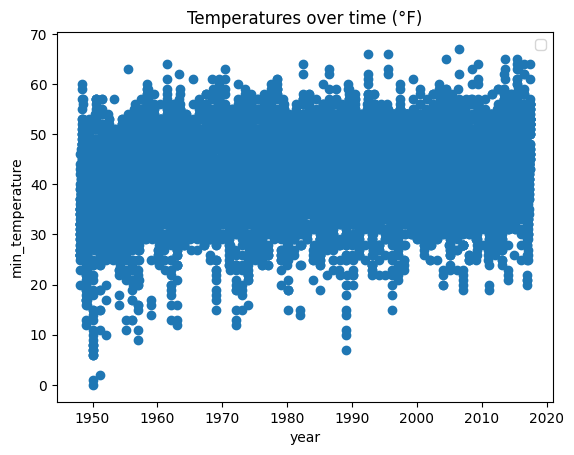

In [1]:
from datetime import datetime
import pandas
from mpl_toolkits import mplot3d
import matplotlib.pyplot as plt

!pip install statsmodels
!wget https://raw.githubusercontent.com/MicrosoftDocs/mslearn-introduction-to-machine-learning/main/Data/seattleWeather_1948-2017.csv

# Load a file that contains weather data for Seattle
data = pandas.read_csv('seattleWeather_1948-2017.csv', parse_dates=['date'])

# Remove all dates after July 1 because we have to to plant onions before summer begins
data = data[[d.month < 7 for d in data.date]].copy()


# Convert the dates into numbers so we can use them in our models
# We make a year column that can contain fractions. For example,
# 1948.5 is halfway through the year 1948
data["year"] = [(d.year + d.timetuple().tm_yday / 365.25) for d in data.date]

# Let's take a quick look at our data
plt.scatter(data["year"], data["min_temperature"])

# add labels and legend
plt.xlabel("year")
plt.ylabel("min_temperature")
plt.title("Temperatures over time (°F)")
plt.legend()

## Ajuste automático de un modelo

Ajustemos una línea a estos datos utilizando una librería existente.

In [2]:
import statsmodels.formula.api as smf

# Perform linear regression to fit a line to our data
# NB OLS uses the sum or mean of squared differences as a cost function,
# which we're familiar with from our last exercise 
model = smf.ols(formula = "min_temperature ~ year", data = data).fit()

# Print the model
intercept = model.params[0]
slope = model.params[1]

print(f"The model is: y = {slope:0.3f} * X + {intercept:0.3f}")

The model is: y = 0.063 * X + -83.073


¡Oh, algo de matemáticas! No dejes que eso te preocupe. Es bastante común que las etiquetas y las características se representen como `Y` y `X`, respectivamente.
Aquí:

* `Y` es la temperatura (°F).
* `X` es el año.
* -83 es un *parámetro del modelo* que actúa como el desplazamiento de la línea.
* 0.063 es un *parámetro del modelo* que define la pendiente de la línea (en °F por año).

Entonces, esta pequeña ecuación indica que el modelo estima la temperatura multiplicando el año por `0.063` y luego restando `83`.

¿Cómo calculó la librería estos valores? Veamos el proceso.

## Selección del modelo

El primer paso siempre es seleccionar un modelo. Reutilicemos el modelo que usamos en ejercicios anteriores.

In [3]:
class MyModel:

    def __init__(self):
        '''
        Creates a new MyModel
        '''
        # Straight lines described by two parameters:
        # The slope is the angle of the line
        self.slope = 0
        # The intercept moves the line up or down
        self.intercept = 0

    def predict(self, date):
        '''
        Estimates the temperature from the date
        '''
        return date * self.slope + self.intercept

    def get_summary(self):
        '''
        Returns a string that summarises the model
        '''
        return f"y = {self.slope} * x + {self.intercept}"

print("Model class ready")

Model class ready


## Ajustando nuestro modelo con descenso de gradiente

El método automático utilizó el método de *mínimos cuadrados ordinarios* (OLS), que es la forma estándar de ajustar una línea. OLS usa la media (o suma) de las diferencias al cuadrado como función de costo. (Recuerda nuestra experimentación con la suma de diferencias al cuadrado en el ejercicio anterior). Vamos a replicar el ajuste de la línea anterior y desglosar cada paso para poder observarlo en acción.

Recuerda que en cada iteración, nuestro entrenamiento realiza tres pasos:

1. Estimación de `Y` (temperatura) a partir de `X` (año).

2. Cálculo de la función de costo y su pendiente.

3. Ajuste de nuestro modelo de acuerdo con esta pendiente.

Nota que *para mantener las cosas simples, nos centraremos en estimar un parámetro (la pendiente de la línea) por ahora*.


Observa cómo el costo cambia tanto con la intersección como con la pendiente de la línea. Esto se debe a que nuestro modelo tiene una pendiente y una intersección, y ambos afectan qué tan bien la línea se ajusta a los datos. Una consecuencia de esto es que el gradiente de la función de costo también debe describirse con dos números: uno para la intersección y otro para la pendiente de la línea.

Nuestro punto más bajo en el gráfico es la ubicación de la mejor ecuación de línea para nuestros datos: una pendiente de 0.063 y una intersección de -83. Intentemos entrenar un modelo para encontrar este punto.

### Implementación del descenso de gradiente

Para implementar el descenso de gradiente, necesitamos un método que pueda calcular el gradiente de la curva anterior.


In [4]:
import numpy as np

x = data.year
temperature_true = data.min_temperature

# Here, we set:
#   x to a range of potential model intercepts
#   y to a range of potential model slopes
#   z as the cost for that combination of model parameters   

# Choose a range of intercepts and slopes values
intercepts = np.linspace(-100,-70,10)
slopes = np.linspace(0.060,0.07,10)


# Set a cost function. This will be the mean of squared differences
def cost_function(temperature_estimate):
    """
    Calculates cost for a given temperature estimate
    Our cost function is the mean of squared differences (a.k.a. mean squared error)
    """
    # Note that with NumPy to square each value, we use **
    return np.mean((temperature_true - temperature_estimate) ** 2)

def predict_and_calc_cost(intercept, slope):
    '''
    Uses the model to make a prediction, then calculates the cost 
    '''

    # Predict temperature by using these model parameters
    temperature_estimate = x * slope + intercept

    # Calculate cost
    return cost_function(temperature_estimate)

def calculate_gradient(temperature_estimate):
    """
    This calculates the gradient for a linear regession 
    by using the Mean Squared Error cost function
    """

    # The partial derivatives of MSE are as follows
    # You don't need to be able to do this just yet, but
    # it's important to note that these give you the two gradients
    # that we need to train our model
    error = temperature_estimate - temperature_true
    grad_intercept = np.mean(error) * 2
    grad_slope = (x * error).mean() * 2

    return grad_intercept, grad_slope

print("Function is ready!")

Function is ready!


Ahora solo necesitamos una suposición inicial y un bucle que la actualice en cada iteración.

In [5]:
def gradient_descent(learning_rate, number_of_iterations):
    """
    Performs gradient descent for a one-variable function. 

    learning_rate: Larger numbers follow the gradient more aggressively
    number_of_iterations: The maximum number of iterations to perform
    """

    # Our starting guess is y = 0 * x - 83
    # We're going to start with the correct intercept so that 
    # only the line's slope is estimated. This is just to keep
    # things simple for this exercise
    model = MyModel()
    model.intercept = -83
    model.slope = 0

    for i in range(number_of_iterations):
        # Calculate the predicted values
        predicted_temperature = model.predict(x)

        # == OPTIMIZER ===
        # Calculate the gradient
        _, grad_slope = calculate_gradient(predicted_temperature)
        # Update the estimation of the line
        model.slope -= learning_rate * grad_slope

        # Print the current estimation and cost every 100 iterations
        if( i % 100 == 0):
            estimate = model.predict(x)
            cost = cost_function(estimate)
            print("Next estimate:", model.get_summary(), f"Cost: {cost}")

    # Print the final model
    print(f"Final estimate:", model.get_summary())

# Run gradient descent
gradient_descent(learning_rate=1E-9, number_of_iterations=1000)

Next estimate: y = 0.0004946403321335834 * x + -83 Cost: 15374.06481788891
Next estimate: y = 0.034564263954523104 * x + -83 Cost: 3218.0503324264355
Next estimate: y = 0.050035120236006536 * x + -83 Cost: 711.4491469584556
Next estimate: y = 0.05706036350652576 * x + -83 Cost: 194.5815905316767
Next estimate: y = 0.060250493523378544 * x + -83 Cost: 88.00218235322374
Next estimate: y = 0.061699116600551045 * x + -83 Cost: 66.02523660294689
Next estimate: y = 0.06235692954504888 * x + -83 Cost: 61.493534346710646
Next estimate: y = 0.0626556393176375 * x + -83 Cost: 60.55908578536231
Next estimate: y = 0.06279128202425543 * x + -83 Cost: 60.36640010911301
Next estimate: y = 0.06285287674109104 * x + -83 Cost: 60.326667831309834
Final estimate: y = 0.06288066221361607 * x + -83


Nuestro modelo encontró la respuesta correcta, pero necesitó varios pasos. Al observar la salida, podemos ver cómo avanzó progresivamente hacia la solución correcta.

Ahora bien, ¿qué ocurre si hacemos que la tasa de aprendizaje sea más rápida? Esto significa dar pasos más grandes.

In [6]:
gradient_descent(learning_rate=1E-8, number_of_iterations=200)

Next estimate: y = 0.004946403321335834 * x + -83 Cost: 13267.277888290606
Next estimate: y = 0.06288803098785394 * x + -83 Cost: 60.31736349245315
Final estimate: y = 0.0629041077135948 * x + -83


Nuestro modelo parece haber encontrado la solución más rápido. Sin embargo, si aumentamos aún más la tasa, las cosas no salen tan bien:

In [7]:
gradient_descent(learning_rate=5E-7, number_of_iterations=500)

Next estimate: y = 0.24732016606679166 * x + -83 Cost: 133774.64171441036
Next estimate: y = 9.500952345613598e+45 * x + -83 Cost: 3.549071667291539e+98
Next estimate: y = 4.894806810765144e+92 * x + -83 Cost: 9.420015144175315e+191
Next estimate: y = 2.52176127646553e+139 * x + -83 Cost: 2.500278766819332e+285
Next estimate: y = 1.2991891572707298e+186 * x + -83 Cost: inf
Final estimate: y = -2.2830799448007263e+232 * x + -83


Observa cómo el costo empeora en cada iteración.

Esto sucede porque los pasos que estaba dando el modelo eran demasiado grandes. Aunque se dirigía hacia la solución correcta, se pasó de largo y en realidad empeoró en cada intento.

Para cada modelo, existe una tasa de aprendizaje ideal. Encontrarla requiere experimentación.

## Ajustando múltiples variables simultáneamente

Aquí solo ajustamos una variable para mantener las cosas simples. Expandir esto a múltiples variables requiere solo algunos pequeños cambios en el código:

* Necesitamos actualizar más de una variable en el ciclo de descenso de gradiente.
* Necesitamos hacer algo de preprocesamiento de los datos, como mencionamos en un ejercicio anterior. Veremos cómo y por qué en materiales posteriores.

## Resumen

¡Bien hecho! En esta unidad:

* Vimos el descenso de gradiente en acción.
* Observamos cómo cambiar la tasa de aprendizaje puede mejorar la velocidad de entrenamiento de un modelo.
* Aprendimos que cambiar la tasa de aprendizaje también puede producir modelos inestables.

Quizás hayas notado que aquí la línea entre la función de costo y el optimizador se volvió un poco difusa. No te preocupes por eso. Esto ocurre comúnmente, ya que aunque son conceptualmente distintos, sus matemáticas a veces se entrelazan.



En este módulo aprendimos cómo funciona el **descenso de gradiente** en un modelo de regresión lineal:

* El entrenamiento consiste en tres pasos: estimar `Y` a partir de `X`, calcular la función de costo y ajustar los parámetros según la pendiente de esta función.
* El **tasa de aprendizaje (learning rate)** determina el tamaño de los pasos:

  * Si es adecuada, el modelo converge más rápido.
  * Si es demasiado baja, el entrenamiento es lento.
  * Si es demasiado alta, el modelo puede volverse inestable y no converger.
* Cada modelo requiere experimentar para encontrar una tasa de aprendizaje óptima.
* Aunque aquí se trabajó con una sola variable, el método se extiende fácilmente a múltiples variables con pequeños cambios en el código y preprocesamiento de datos.
* La frontera entre **función de costo** y **optimizador** a veces se percibe difusa, porque aunque son conceptos distintos, sus matemáticas se relacionan estrechamente.

El descenso de gradiente ajusta los parámetros paso a paso para minimizar el costo; la elección adecuada de la tasa de aprendizaje es clave para entrenar modelos estables y eficientes.
